# Pengelompokan 10 Coin Besar Berdasarkan Karakter

**Konteks**: user ingin konsep portofolio seperti saham — pegang beberapa coin, rugi di satu aset
ditutup untung aset lain, modal di-rebalance — dengan strategi yang **spesifik per kelompok coin**
(jalan tengah antara "satu aturan untuk semua" dan "strategi khusus per coin" yang rawan overfit).
Notebook ini hanya **mengelompokkan**; strategi per kelompok diuji di notebook berikutnya.

### Universe: 10 coin yang **sudah besar sejak lama**
BTC, ETH, BNB, XRP, ADA, DOGE, LINK, TRX, LTC, BCH — bukan 10 coin terbesar *hari ini* (menghindari
bias memilih coin yang baru sukses, seperti SUI di notebook 07).

### Data
Histori diperpanjang ke 2018 (Binance Vision), disimpan terpisah sebagai `*_1d_since2018.csv`
supaya data notebook 07–13 tidak berubah.

### Periode
Pengelompokan **hanya memakai 2018-01 → 2022-12** (periode pengembangan). 2023-01 → 2026-06
disimpan untuk uji akhir strategi nanti — tidak disentuh di sini.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

from data_source.loader import load_symbol
from research.single_position import Panel, run_exposure, metrics, BTC

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
COINS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "LINKUSDT", "TRXUSDT", "LTCUSDT", "BCHUSDT"]
DEV = ("2018-01-01", "2022-12-31")
data = {s: load_symbol(s, "1d", "since2018") for s in COINS}
P = Panel(data, "2018-01-01", "2026-06-30")
inv = pd.DataFrame({s: dict(mulai=d.index.min().date(), akhir=d.index.max().date(), hari=len(d),
                            hari_di_periode_dev=int(((d.index >= DEV[0]) & (d.index <= DEV[1])).sum()))
                    for s, d in data.items()}).T
inv

,mulai,akhir,hari,hari_di_periode_dev
BTCUSDT,2018-01-01,2026-06-30,3103,1826
ETHUSDT,2018-01-01,2026-06-30,3103,1826
BNBUSDT,2018-01-01,2026-06-30,3103,1826
XRPUSDT,2018-05-04,2026-06-30,2980,1703
ADAUSDT,2018-04-17,2026-06-30,2997,1720
DOGEUSDT,2019-07-05,2026-06-30,2553,1276
LINKUSDT,2019-01-16,2026-06-30,2723,1446
TRXUSDT,2018-06-11,2026-06-30,2942,1665
LTCUSDT,2018-01-01,2026-06-30,3103,1826
BCHUSDT,2019-11-28,2026-06-30,2407,1130


## 1. Fitur karakter per coin (periode pengembangan 2018–2022)

| Fitur | Arti |
|---|---|
| `volatilitas` | standar deviasi return harian × √365 |
| `korelasi_btc`, `beta_btc` | seberapa ikut BTC (beta 1.5 = bergerak 1,5× BTC) |
| `tangkap_crash` | rata-rata return coin di hari BTC turun > 5%, dibagi rata-rata return BTC di hari itu |
| `tangkap_rally` | sama, untuk hari BTC naik > 5% |
| `variance_ratio_20` | > 1 = cenderung **tren**, < 1 = cenderung **memantul balik** (mean-reverting) |
| `edge_tren` | Sharpe filter tren (close > SMA100 coin sendiri) − Sharpe buy & hold |
| `sharpe_mean_rev` | Sharpe aturan mean-reversion: beli saat close < Bollinger bawah (20, 2σ), jual saat close > SMA20 |
| `max_dd_hold`, `kurtosis`, `hari_terburuk` | risiko ekstrem |

In [2]:
dev_dates = P.dates[(P.dates >= DEV[0]) & (P.dates <= DEV[1])]
R = P.close.pct_change().loc[dev_dates]
btc = R[BTC]
crash_days, rally_days = btc < -0.05, btc > 0.05

def variance_ratio(r, q):
    r = r.dropna()
    rq = r.rolling(q).sum().dropna()
    return rq.var() / (q * r.var())

def mean_rev_signal(close):
    ma, sd = close.rolling(20).mean(), close.rolling(20).std()
    s, out = False, []
    for c, m, b in zip(close, ma, ma - 2 * sd):
        if not s and c < b:
            s = True
        elif s and c > m:
            s = False
        out.append(float(s))
    return pd.Series(out, index=close.index)

feats = {}
for s in COINS:
    r = R[s].dropna()
    both = pd.concat([r, btc], axis=1).dropna()
    first = r.index.min() + pd.Timedelta(days=100)       # warm-up SMA100
    per = (str(max(first, pd.Timestamp(DEV[0])).date()), DEV[1])
    hold = pd.Series(1.0, index=P.dates)
    trend_w = (P.close[s] > P.close[s].rolling(100, min_periods=100).mean()).astype(float)
    m_hold = metrics(*run_exposure(P, hold, *per, sym=s))
    m_tr = metrics(*run_exposure(P, trend_w, *per, sym=s))
    m_mr = metrics(*run_exposure(P, mean_rev_signal(P.close[s]), *per, sym=s))
    both.columns = ["coin", "btc"]
    cd, rd = both["btc"] < -0.05, both["btc"] > 0.05      # hari BTC crash / rally (tanggal yang sama)
    feats[s] = dict(
        volatilitas=r.std() * np.sqrt(365),
        korelasi_btc=both["coin"].corr(both["btc"]),
        beta_btc=np.cov(both["coin"], both["btc"])[0, 1] / both["btc"].var(),
        tangkap_crash=both.loc[cd, "coin"].mean() / both.loc[cd, "btc"].mean(),
        tangkap_rally=both.loc[rd, "coin"].mean() / both.loc[rd, "btc"].mean(),
        variance_ratio_20=variance_ratio(r, 20),
        edge_tren=m_tr["sharpe"] - m_hold["sharpe"],
        sharpe_tren=m_tr["sharpe"], sharpe_hold=m_hold["sharpe"], sharpe_mean_rev=m_mr["sharpe"],
        max_dd_hold=m_hold["max_dd"], max_dd_tren=m_tr["max_dd"],
        kurtosis=stats.kurtosis(r), hari_terburuk=r.min(),
    )
F = pd.DataFrame(feats).T
fmt = F.copy().astype(object)
for c in F.columns:
    fmt[c] = F[c].map(lambda v: f"{v:+.0%}" if c in ("volatilitas", "max_dd_hold", "max_dd_tren", "hari_terburuk") else f"{v:.2f}")
fmt

,volatilitas,korelasi_btc,beta_btc,tangkap_crash,tangkap_rally,variance_ratio_20,edge_tren,sharpe_tren,sharpe_hold,sharpe_mean_rev,max_dd_hold,max_dd_tren,kurtosis,hari_terburuk
BTCUSDT,+75%,1.00,1.00,1.00,1.00,1.04,0.46,1.05,0.58,-0.23,-77%,-39%,8.01,-40%
ETHUSDT,+98%,0.82,1.07,1.15,0.91,1.09,0.09,0.77,0.68,0.09,-90%,-75%,5.65,-45%
BNBUSDT,+114%,0.65,0.98,1.09,0.79,1.09,0.02,1.13,1.11,0.22,-76%,-78%,24.34,-44%
XRPUSDT,+113%,0.60,0.95,1.04,0.78,1.08,-0.52,0.08,0.60,-0.04,-83%,-80%,15.41,-42%
ADAUSDT,+110%,0.70,1.06,1.20,0.83,1.18,0.70,1.33,0.62,-0.31,-92%,-67%,4.15,-41%
DOGEUSDT,+255%,0.31,1.09,1.05,1.30,1.23,-0.13,0.91,1.04,0.54,-92%,-92%,580.22,-38%
LINKUSDT,+126%,0.59,1.03,1.19,0.79,0.96,-0.36,0.81,1.17,0.27,-90%,-86%,9.66,-48%
TRXUSDT,+102%,0.66,0.94,1.06,0.72,0.86,-0.42,0.30,0.73,-0.23,-78%,-70%,7.45,-44%
LTCUSDT,+103%,0.80,1.10,1.20,0.96,0.87,0.16,0.53,0.38,-0.13,-89%,-83%,5.66,-39%
BCHUSDT,+111%,0.76,1.14,1.31,1.00,0.81,-0.30,-0.08,0.22,-0.03,-94%,-88%,14.47,-46%


## 2. Kedekatan pergerakan harian (korelasi return)

Kalau semua coin sangat berkorelasi, diversifikasi antar coin tidak banyak melindungi saat crash.

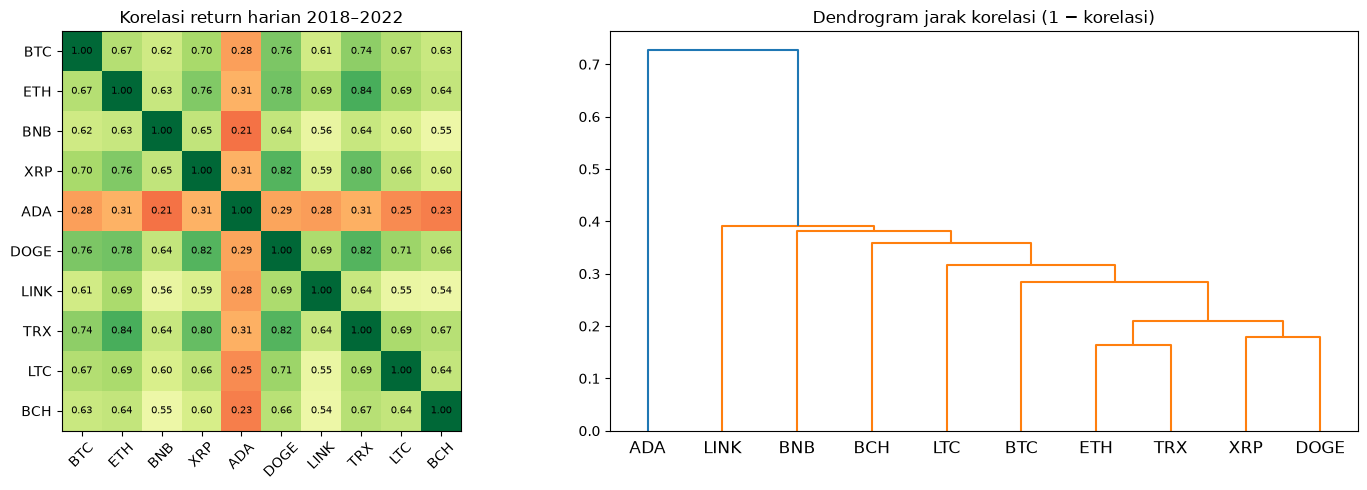

Korelasi antar coin: rata-rata 0.59, terendah 0.21 (('BNBUSDT', 'DOGEUSDT')), tertinggi 0.84 (('BCHUSDT', 'LTCUSDT'))
Rata-rata korelasi di hari BTC crash (>5% turun): 0.70 | hari biasa: 0.48


In [3]:
C = R.corr()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
im = axes[0].imshow(C, cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_xticks(range(len(COINS))); axes[0].set_xticklabels([s[:-4] for s in COINS], rotation=45)
axes[0].set_yticks(range(len(COINS))); axes[0].set_yticklabels([s[:-4] for s in COINS])
for i in range(len(COINS)):
    for j in range(len(COINS)):
        axes[0].text(j, i, f"{C.iat[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[0].set_title("Korelasi return harian 2018–2022")
dist = squareform(1 - C.to_numpy(), checks=False)
dendrogram(linkage(dist, "average"), labels=[s[:-4] for s in COINS], ax=axes[1])
axes[1].set_title("Dendrogram jarak korelasi (1 − korelasi)")
plt.tight_layout(); plt.show()
off = C.where(~np.eye(len(C), dtype=bool)).stack()
print(f"Korelasi antar coin: rata-rata {off.mean():.2f}, terendah {off.min():.2f} ({off.idxmin()}), tertinggi {off.max():.2f} ({off.idxmax()})")

# korelasi saat crash vs hari biasa
cc = R[crash_days].corr().where(~np.eye(len(C), dtype=bool)).stack().mean()
nc = R[~crash_days & ~rally_days].corr().where(~np.eye(len(C), dtype=bool)).stack().mean()
print(f"Rata-rata korelasi di hari BTC crash (>5% turun): {cc:.2f} | hari biasa: {nc:.2f}")

## 3. Pengelompokan berdasarkan karakter (hierarchical clustering, Ward)

Fitur yang dipakai (distandarkan): volatilitas, beta ke BTC, tangkap crash, variance ratio,
edge tren, Sharpe mean-reversion, kurtosis.

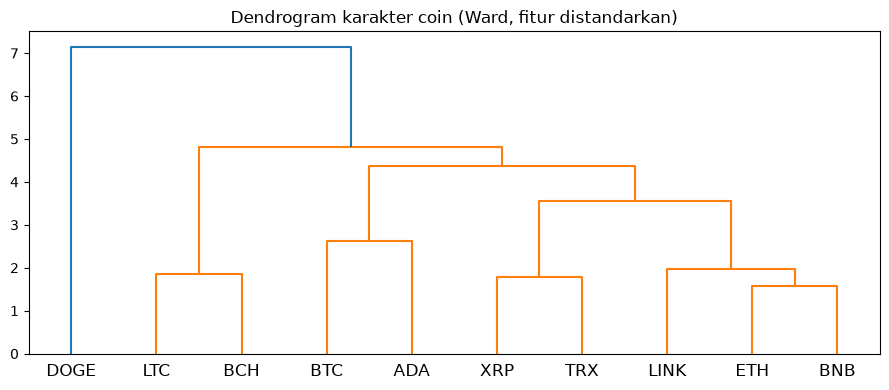

,k=2,k=3,k=4
BTC,1,2,2
ETH,1,2,3
BNB,1,2,3
XRP,1,2,3
ADA,1,2,2
DOGE,2,3,4
LINK,1,2,3
TRX,1,2,3
LTC,1,1,1
BCH,1,1,1


In [4]:
USE = ["volatilitas", "beta_btc", "tangkap_crash", "variance_ratio_20", "edge_tren", "sharpe_mean_rev", "kurtosis"]
Z = (F[USE] - F[USE].mean()) / F[USE].std()
L = linkage(Z.to_numpy(), "ward")
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(L, labels=[s[:-4] for s in COINS], ax=ax)
ax.set_title("Dendrogram karakter coin (Ward, fitur distandarkan)"); plt.tight_layout(); plt.show()
groups = pd.DataFrame({f"k={k}": fcluster(L, k, "maxclust") for k in (2, 3, 4)}, index=[s[:-4] for s in COINS])
groups

In [5]:
K = 3
F["kelompok"] = fcluster(L, K, "maxclust")
prof = F.groupby("kelompok")[USE + ["sharpe_tren", "sharpe_hold", "max_dd_hold", "max_dd_tren"]].mean()
prof.insert(0, "anggota", F.groupby("kelompok").apply(lambda g: ", ".join(s[:-4] for s in g.index)))
out = prof.copy().astype(object)
for c in prof.columns[1:]:
    out[c] = prof[c].map(lambda v: f"{v:+.0%}" if c in ("volatilitas", "max_dd_hold", "max_dd_tren") else f"{v:.2f}")
print(f"Profil rata-rata tiap kelompok (k = {K}):")
out

Profil rata-rata tiap kelompok (k = 3):


,anggota,volatilitas,beta_btc,tangkap_crash,variance_ratio_20,edge_tren,sharpe_mean_rev,kurtosis,sharpe_tren,sharpe_hold,max_dd_hold,max_dd_tren
kelompok,,,,,,,,,,,,
1,"LTC, BCH",+107%,1.12,1.26,0.84,-0.07,-0.08,10.07,0.23,0.30,-92%,-85%
2,"BTC, ETH, BNB, XRP, ADA, LINK, TRX",+105%,1.00,1.10,1.04,-0.00,-0.03,10.67,0.78,0.79,-84%,-71%
3,DOGE,+255%,1.09,1.05,1.23,-0.13,0.54,580.22,0.91,1.04,-92%,-92%


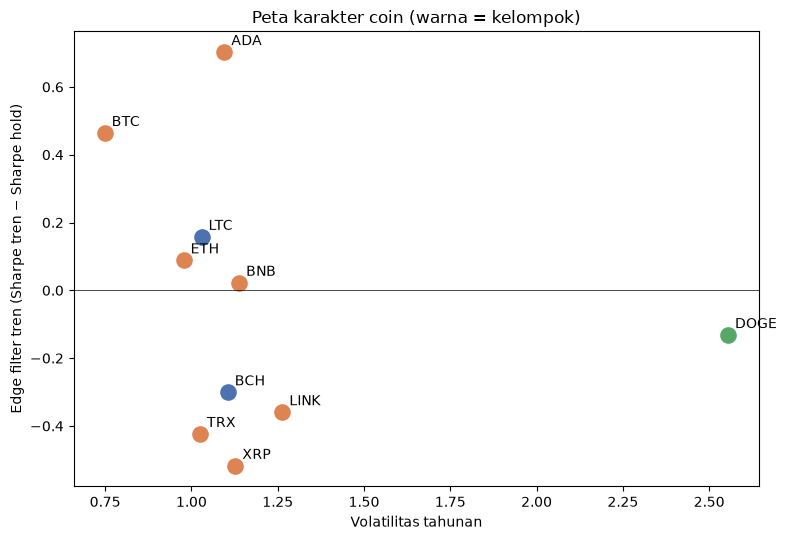

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {1: "#4C72B0", 2: "#DD8452", 3: "#55A868", 4: "#C44E52"}
for s, row in F.iterrows():
    ax.scatter(row["volatilitas"], row["edge_tren"], s=120, color=colors[int(row["kelompok"])])
    ax.annotate(s[:-4], (row["volatilitas"], row["edge_tren"]), xytext=(5, 5), textcoords="offset points")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Volatilitas tahunan"); ax.set_ylabel("Edge filter tren (Sharpe tren − Sharpe hold)")
ax.set_title("Peta karakter coin (warna = kelompok)"); plt.tight_layout(); plt.show()

## Kesimpulan

### 3 kelompok coin (k = 3, data 2018–2022)
| Kelompok | Anggota | Ciri |
|---|---|---|
| **1. Coin utama** | BTC, ETH, BNB, XRP, ADA, LINK, TRX | beta ≈ 1.0 (bergerak seirama BTC), volatilitas ±100%/tahun, cenderung **tren** (variance ratio > 1) |
| **2. Fork lama** | LTC, BCH | **jatuh lebih dalam dari BTC saat crash** (tangkap crash 1.2–1.3×), naik lebih lemah saat rally, cenderung **memantul balik** (variance ratio < 1), buy & hold paling buruk (Sharpe 0.22–0.38, DD −89% s/d −94%) |
| **3. Meme** | DOGE | sangat liar (volatilitas 255%, kurtosis 580 — lonjakan ekstrem Jan 2021), korelasi ke BTC paling rendah (0.31), satu-satunya coin yang cocok **mean-reversion** (Sharpe 0.54) |

### Temuan penting untuk konsep portofolio
1. **Diversifikasi melemah tepat saat dibutuhkan**: korelasi rata-rata antar coin 0.48 di hari biasa,
   naik ke **0.70 di hari BTC crash**. Portofolio banyak coin **tetap butuh filter pasar** (seperti notebook 13)
   — "rugi di satu coin ditutup coin lain" hampir tidak terjadi saat crash.
2. **Filter tren tidak cocok untuk semua coin**: edge tren positif di BTC (+0.46) dan ADA (+0.70), tapi
   negatif di XRP (−0.52), TRX (−0.42), LINK (−0.36). Namun angka per coin ini dari 4–5 tahun data
   (sedikit trade) → **jangan dipakai untuk memilih strategi per coin** (rawan overfit); lebih aman di level kelompok.
3. **Kelompok 2 (LTC, BCH) paling lemah** — kandidat untuk dikeluarkan atau diberi porsi kecil.
4. **DOGE** berbeda sendiri → kalau dipakai, porsinya harus kecil dan strateginya berbeda.

### Catatan jujur
- Hanya 10 coin: kelompok 2 & 3 berisi 1–2 coin, jadi strategi "khusus kelompok" untuk mereka praktis
  sama dengan strategi khusus per coin (datanya sedikit).
- Karakter DOGE sangat dipengaruhi satu kejadian (pump 2021).

### Langkah berikutnya (notebook 15, perlu keputusan user)
Uji portofolio dengan aturan yang ditetapkan **sebelum** melihat periode uji 2023–2026, contoh:
- Kelompok 1 → filter tren per coin + filter pasar BTC/FGI (notebook 13), porsi sama / berbasis volatilitas.
- Kelompok 2 → dikeluarkan (atau mean-reversion).
- Kelompok 3 → porsi kecil tetap, mean-reversion.
- Rebalance mingguan vs bulanan, biaya dihitung penuh. Pembanding: strategi 13 (BTC saja).